# LGBM + SHAP 해석 분석

OLS 예측에서 확정한 `final_aic_features`를 사용해 LGBM을 전체 데이터로 학습하고,
SHAP으로 변수의 비선형 효과를 분해한다. OLS 해석 결과(β)와 변수별로 매칭하여
**견고한 효과 / 비선형 효과 / 상호작용 의심 / 선형 효과 위주 / 무의미** 케이스를 분류한다.

- 입력: `../data/Finance_Final/dataset4_derived_full_with_dummies.csv`
- 설정: `../outputs/baseline/final_features.json`
- OLS 해석: `../outputs/baseline/ols_interpretation_coefficients.csv`
- 출력: `../outputs/baseline/lgbm_shap_summary.csv`, `interpretation_compare.csv`, `shap_values.npy`, PNG 3종

## 1. 설정 로드 + 데이터 준비

In [1]:
# import sys
# !{sys.executable} -m pip install shap

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
import shap
from sklearn.metrics import r2_score, mean_squared_error

DATA_PATH = Path('../data/Finance_Final/dataset4_derived_full_with_dummies.csv')
BASELINE_DIR = Path('../outputs/baseline')
CFG_PATH = BASELINE_DIR / 'final_features.json'
OLS_PATH = BASELINE_DIR / 'ols_interpretation_coefficients.csv'

with open(CFG_PATH) as f:
    cfg = json.load(f)

target = cfg['target']
final_aic_features = cfg['final_aic_features']
print(f'target: {target}')
print(f'n_features: {len(final_aic_features)}')
print('features:', final_aic_features)

target: oil_diff_target
n_features: 19
features: ['OilPrice', 'RealInterestRate', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'TreasuryYield', 'oil_diff_lag1', 'MA_ratio', 'MA_5_gt_MA_20', 'vix_high', 'is_friday', 'gfc_2008_shock', 'gfc_2008_regime', 'opec_2014_window', 'covid_2020_window', 'war_2022_window', 'cond_opec_cut']


In [3]:
df = pd.read_csv(DATA_PATH)
needed = final_aic_features + [target]
df_model = df[needed].dropna().reset_index(drop=True)

X = df_model[final_aic_features].copy()
y = df_model[target].copy()
print('전체 표본 수:', len(df_model))
print('X shape:', X.shape, '/ y shape:', y.shape)

전체 표본 수: 4547
X shape: (4547, 19) / y shape: (4547,)


## 2. LGBM 학습 (전체 데이터, 튜닝 없음)

In [4]:
lgbm = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
)
lgbm.fit(X, y)

pred = lgbm.predict(X)
r2 = r2_score(y, pred)
rmse = np.sqrt(mean_squared_error(y, pred))
print(f'in-sample R²  : {r2:.4f}')
print(f'in-sample RMSE: {rmse:.4f}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000404 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2280
[LightGBM] [Info] Number of data points in the train set: 4547, number of used features: 18
[LightGBM] [Info] Start training from score 0.000378


in-sample R²  : 0.5305
in-sample RMSE: 1.3993


## 3. SHAP 값 계산

In [5]:
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X)
expected_value = explainer.expected_value

print('shap_values shape:', np.array(shap_values).shape)
print('expected_value:', expected_value)

shap_values shape: (4547, 19)
expected_value: 0.0003782704483863414


## 4. SHAP 요약 표

In [6]:
shap_arr = np.array(shap_values)

shap_summary = pd.DataFrame({
    'variable': final_aic_features,
    'mean_abs_shap': np.abs(shap_arr).mean(axis=0),
    'mean_shap_signed': shap_arr.mean(axis=0),
    'sign_positive_ratio': (shap_arr > 0).mean(axis=0),
})
shap_summary = shap_summary.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_summary['rank'] = np.arange(1, len(shap_summary) + 1)
shap_summary

,variable,mean_abs_shap,mean_shap_signed,sign_positive_ratio,rank
0,MA_ratio,0.136547,0.011229,0.378051,1
1,OilPrice,0.136534,0.002907,0.453046,2
2,oil_diff_lag1,0.108982,0.001084,0.463163,3
3,VIX,0.101576,-0.002339,0.423576,4
4,OPECProduction,0.091388,-0.006134,0.578403,5
5,OilInventories,0.089446,0.001859,0.536618,6
6,TreasuryYield,0.086930,0.000615,0.655597,7
7,RealInterestRate,0.080080,0.000197,0.540136,8
8,CPE,0.072870,0.000836,0.550693,9
9,gfc_2008_shock,0.057836,-0.008053,0.983286,10


## 5. SHAP 시각화

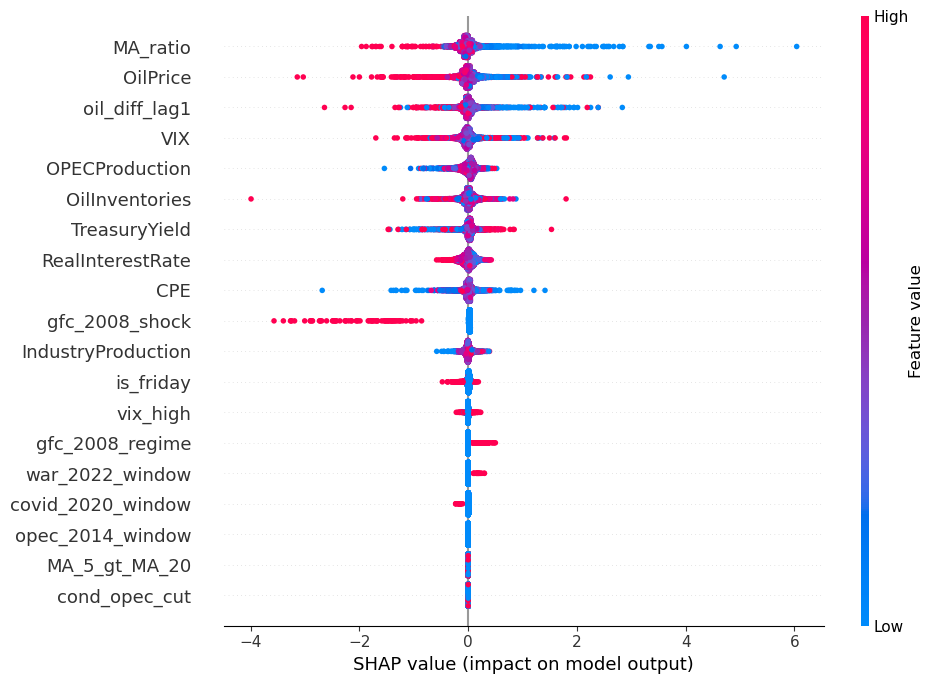

In [7]:
plt.rcParams.update({'font.size': 12})

# beeswarm
shap.summary_plot(shap_values, X, show=False, plot_size=(10, 7))
fig = plt.gcf()
fig.tight_layout()
fig.savefig(BASELINE_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

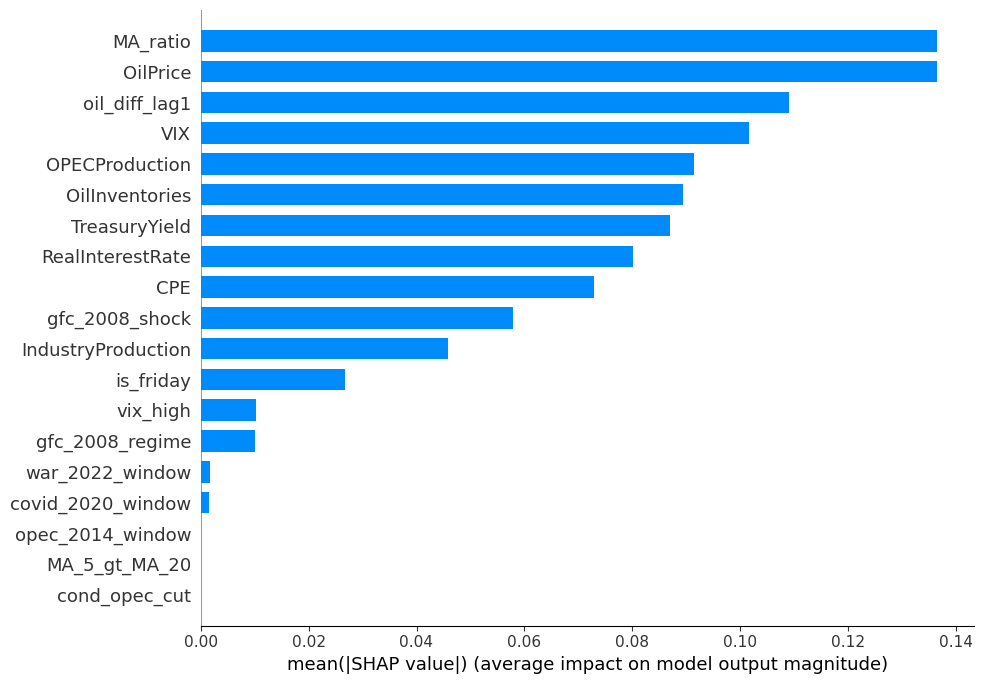

In [8]:
# bar
shap.summary_plot(shap_values, X, plot_type='bar', show=False, plot_size=(10, 7))
fig = plt.gcf()
fig.tight_layout()
fig.savefig(BASELINE_DIR / 'shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

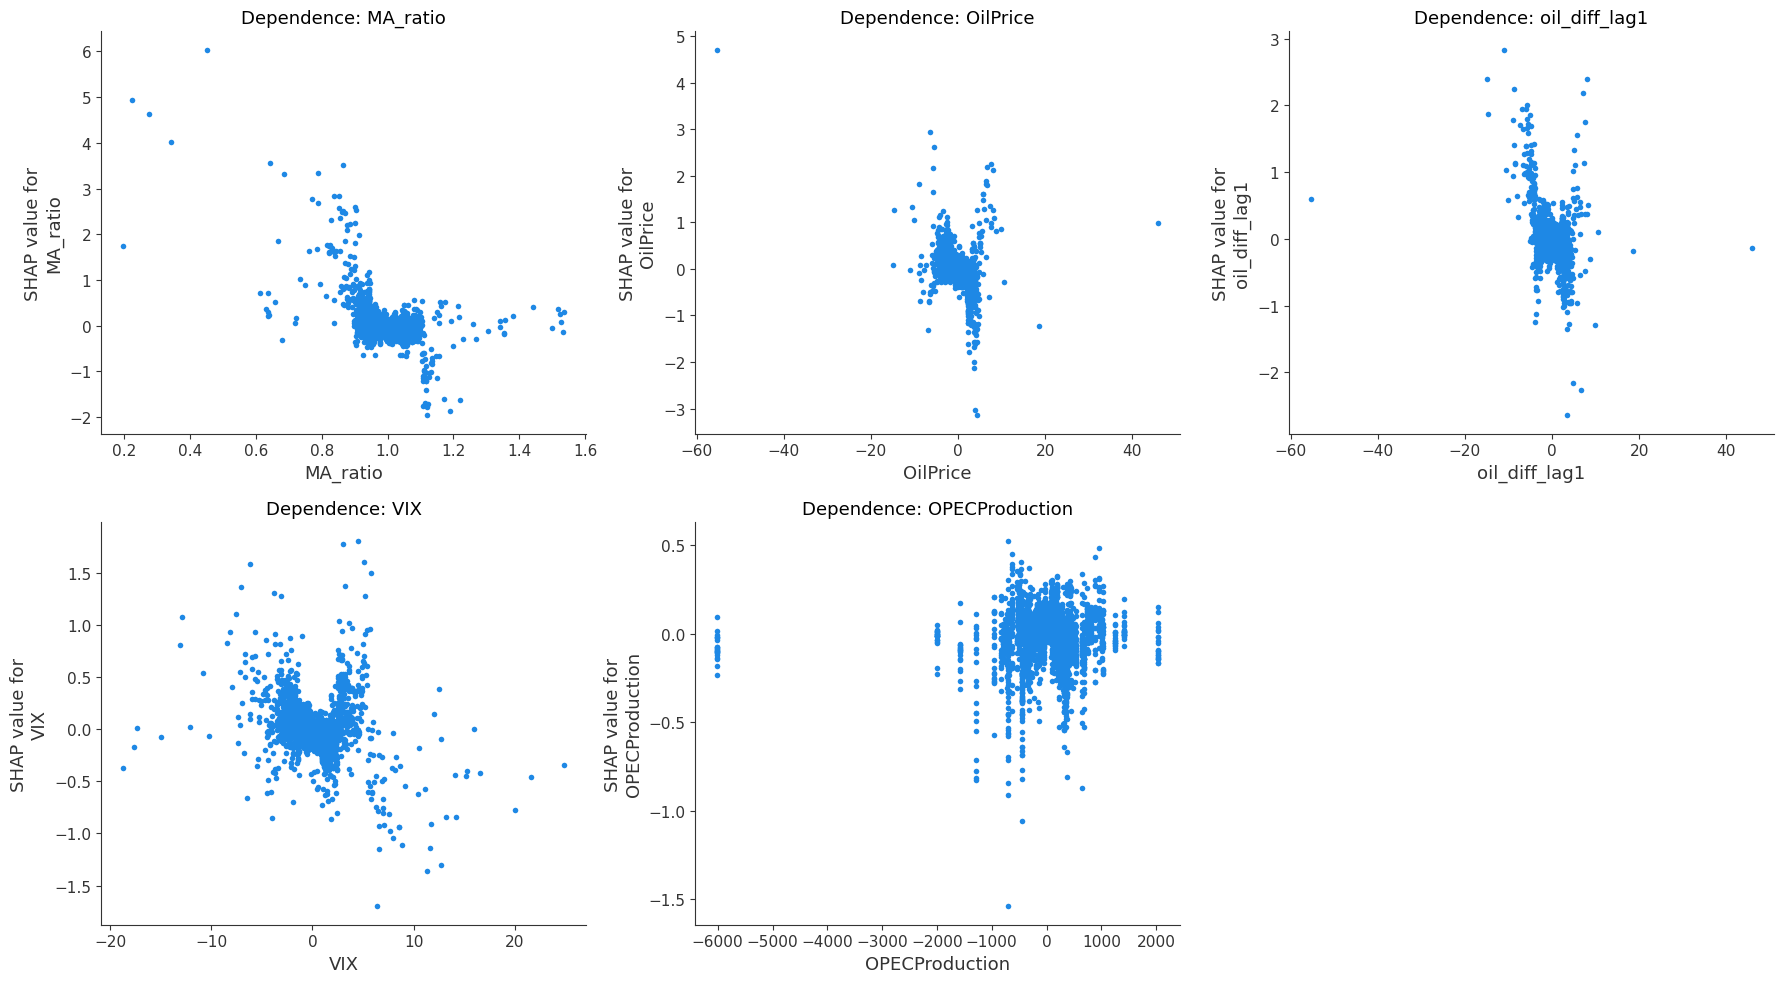

In [9]:
# 상위 5개 dependence plot (해당 변수 값과 SHAP 값의 관계)
top5 = shap_summary['variable'].head(5).tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, var in enumerate(top5):
    shap.dependence_plot(var, shap_values, X, ax=axes[i], show=False, interaction_index=None)
    axes[i].set_title(f'Dependence: {var}', fontsize=13)
axes[-1].axis('off')
fig.tight_layout()
fig.savefig(BASELINE_DIR / 'dependence_top5.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. OLS β ↔ SHAP 비교 표

In [10]:
ols = pd.read_csv(OLS_PATH)
ols.columns = [c.lstrip('\ufeff') for c in ols.columns]
ols = ols.rename(columns={'std_beta': 'std_beta_OLS'})
ols['sig_OLS'] = ols['p_HC3'] < 0.05
ols['sign_OLS'] = np.where(ols['std_beta_OLS'] >= 0, '+', '-')

shap_for_merge = shap_summary.rename(columns={'rank': 'rank_shap'}).copy()
shap_for_merge['sign_SHAP'] = np.where(shap_for_merge['mean_shap_signed'] >= 0, '+', '-')

cmp = ols[['variable', 'std_beta_OLS', 'p_HC3', 'sig_OLS', 'sign_OLS']].merge(
    shap_for_merge[['variable', 'mean_abs_shap', 'rank_shap', 'sign_SHAP']],
    on='variable', how='inner'
)
cmp['sign_match'] = cmp['sign_OLS'] == cmp['sign_SHAP']

# top_n: 변수 19개 → 상위 1/3 ≈ 6개를 '큼'으로 정의
n_feat = len(cmp)
top_n = max(4, n_feat // 3)
shap_top_set = set(cmp.sort_values('mean_abs_shap', ascending=False).head(top_n)['variable'])
beta_top_set = set(cmp.assign(abs_beta=cmp['std_beta_OLS'].abs())
                      .sort_values('abs_beta', ascending=False).head(top_n)['variable'])

def classify(row):
    v = row['variable']
    shap_big = v in shap_top_set
    beta_big = v in beta_top_set
    sig = row['sig_OLS']
    match = row['sign_match']
    if (not sig) and shap_big:
        return '순수 비선형 효과'
    if not match:
        return '상호작용 의심'
    if shap_big and beta_big:
        return '견고한 효과'
    if shap_big and not beta_big:
        return '비선형 추가 효과'
    if beta_big and not shap_big:
        return '선형 효과 위주'
    return '약한 효과'

cmp['case'] = cmp.apply(classify, axis=1)
cmp = cmp.sort_values('rank_shap').reset_index(drop=True)
cmp

,variable,std_beta_OLS,p_HC3,sig_OLS,sign_OLS,mean_abs_shap,rank_shap,sign_SHAP,sign_match,case
0,MA_ratio,-0.286880,0.144816,False,-,0.136547,1,+,False,순수 비선형 효과
1,OilPrice,-0.322940,0.262527,False,-,0.136534,2,+,False,순수 비선형 효과
2,oil_diff_lag1,-0.139351,0.048918,True,-,0.108982,3,+,False,상호작용 의심
3,VIX,-0.059124,0.177360,False,-,0.101576,4,-,True,순수 비선형 효과
4,OPECProduction,-0.111336,0.077454,False,-,0.091388,5,-,True,순수 비선형 효과
5,OilInventories,-0.018774,0.747363,False,-,0.089446,6,+,False,순수 비선형 효과
6,TreasuryYield,0.067139,0.258958,False,+,0.086930,7,+,True,약한 효과
7,RealInterestRate,-0.059646,0.090114,False,-,0.080080,8,+,False,상호작용 의심
8,CPE,-0.219413,0.066105,False,-,0.072870,9,+,False,상호작용 의심
9,gfc_2008_shock,-0.110901,0.217532,False,-,0.057836,10,-,True,약한 효과


## 7. SHAP dependence 심화 분석
→ SHAP 중요도 상위 변수 중심

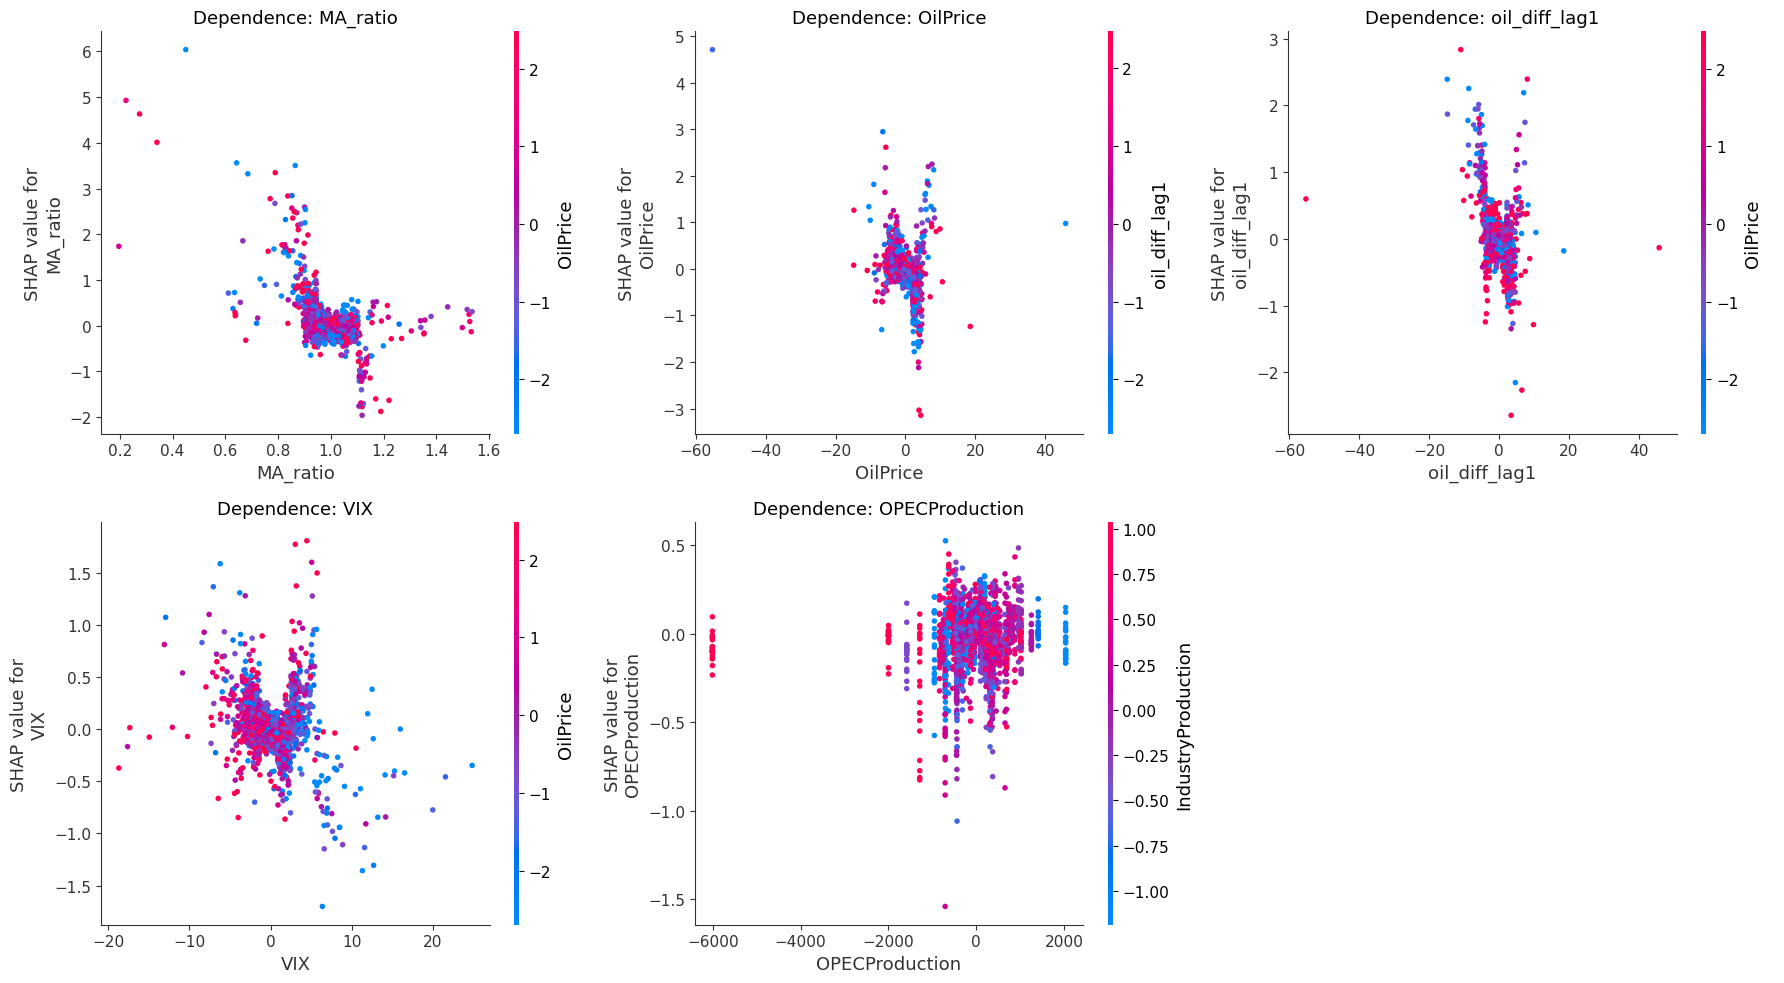

In [11]:
# 상위 5개 dependence plot 심화 분석 (상호작용 후보 확인)
top5 = shap_summary['variable'].head(5).tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, var in enumerate(top5):
    shap.dependence_plot(var, shap_values, X, ax=axes[i], show=False, interaction_index='auto')
    axes[i].set_title(f'Dependence: {var}', fontsize=13)
axes[-1].axis('off')
fig.tight_layout()
fig.savefig(BASELINE_DIR / 'dependence_top5.png', dpi=150, bbox_inches='tight')
plt.show()

- 특정 변수의 SHAP 기여도가 다른 변수의 수준에 따라 어떻게 달라지는지를 시각화한다. 
- 'auto'는 모델 내부에서 dependence plot상 가장 강하게 상호작용하는 후보를 자동 선택한다. 
- 색상이 SHAP 값의 위아래 분포를 뚜렷하게 나눈다면, 해당 변수 간 상호작용 가능성이 있다고 해석할 수 있다.


| 변수 | auto가 선택한 상호작용 후보 | 해석 |
|---|---|---|
| `MA_ratio` | `OilPrice` | 이동평균 비율 효과가 유가 수준에 따라 달라질 가능성 |
| `OilPrice` | `oil_volatility_20` | 유가 수준 효과가 변동성 국면에 따라 달라질 가능성 |
| `oil_volatility_20` | `OilPrice` | 변동성 효과가 유가 수준과 결합되어 나타남 |
| `oil_diff_lag1` | `oil_volatility_20` | 전일 변화 효과가 변동성 국면에 따라 달라짐 |
| `OilInventories` | `oil_volatility_20` | 재고 효과의 강도가 변동성 수준에 따라 달라질 수 있음 |

## 8. 구간별 SHAP 부호 분포

OLS β ↔ SHAP 비교에서는 `mean_shap_signed`를 이용해 변수별 평균적인 방향성을 확인하였다.  
본 절에서는 SHAP 중요도가 높거나 OLS β와 SHAP 평균 부호가 불일치한 변수를 대상으로, 변수 값을 분위수 구간으로 나누어 구간별 SHAP 방향을 확인한다.

- 목적
1. 평균 SHAP 부호가 변수의 효과 방향을 잘 대표하는지 확인한다.
2. 변수 값의 구간에 따라 SHAP 부호가 달라지는지 확인한다.
3. OLS와 SHAP의 부호 불일치가 구간별 효과와 관련되는지 검토한다.

In [12]:
# SHAP 상위 변수 + OLS/SHAP 부호 불일치 변수 추출
top_vars = shap_summary["variable"].head(8).tolist()
mismatch_vars = cmp.loc[~cmp["sign_match"], "variable"].tolist()

target_vars = []
for v in top_vars + mismatch_vars:
    if v in X.columns and v not in target_vars:
        target_vars.append(v)

# 더미/상수형 변수는 구간 분석에서 제외(분위수 구간 분석에 적합하지 X)
target_vars = [
    v for v in target_vars
    if X[v].nunique(dropna=True) > 5 and shap_summary.loc[shap_summary["variable"] == v, "mean_abs_shap"].iloc[0] > 0
]

print("구간별 SHAP 부호 분포 분석 대상:")
print(target_vars)

구간별 SHAP 부호 분포 분석 대상:
['MA_ratio', 'OilPrice', 'oil_diff_lag1', 'VIX', 'OPECProduction', 'OilInventories', 'TreasuryYield', 'RealInterestRate', 'CPE', 'IndustryProduction']


In [13]:
# 변수별 구간 분석
bin_rows = []

for var in target_vars:
    j = final_aic_features.index(var)

    tmp = pd.DataFrame({
        "variable": var,
        "x_value": X[var].values,
        "shap_value": shap_arr[:, j],
    })

    # 분위수 구간 생성
    # 하위 20%, 20~40%, 40~60%, 60~80%, 상위 20%
    tmp["bin"] = pd.qcut(
        tmp["x_value"],
        q=5,
        duplicates="drop"
    )

    # 최솟값, 최댓값, 평균값, 평균 SHAP, 평균 절대 SHAP, 양수 비율, 음수 비율 계산
    grouped = tmp.groupby("bin", observed=True).agg(
        x_min=("x_value", "min"),
        x_max=("x_value", "max"),
        mean_x=("x_value", "mean"),
        mean_shap=("shap_value", "mean"),
        mean_abs_shap=("shap_value", lambda s: np.abs(s).mean()),
        positive_ratio=("shap_value", lambda s: (s > 0).mean()),
        negative_ratio=("shap_value", lambda s: (s < 0).mean()),
    ).reset_index()

    grouped["variable"] = var
    grouped["bin_order"] = np.arange(1, len(grouped) + 1)

    # 구간별 평균 SHAP 부호
    grouped["sign_by_bin"] = np.where(
        grouped["mean_shap"] > 0, "+",
        np.where(grouped["mean_shap"] < 0, "-", "0")
    )

    # 전체 평균 SHAP 부호
    overall_mean = tmp["shap_value"].mean()
    grouped["overall_sign"] = "+" if overall_mean > 0 else ("-" if overall_mean < 0 else "0")

    bin_rows.append(grouped)

shap_bin_summary = pd.concat(bin_rows, ignore_index=True)

display_cols = [
    "variable",
    "bin_order",
    "x_min",
    "x_max",
    "mean_shap",
    "positive_ratio",
    "sign_by_bin",
    "overall_sign",
]

display(shap_bin_summary[display_cols].round(4))

,variable,bin_order,x_min,x_max,mean_shap,positive_ratio,sign_by_bin,overall_sign
0,MA_ratio,1,0.1963,0.9673,0.2601,0.7297,+,+
1,MA_ratio,2,0.9673,0.9941,-0.0086,0.4785,-,+
2,MA_ratio,3,0.9941,1.0129,-0.0627,0.1419,-,+
3,MA_ratio,4,1.0129,1.0333,-0.0425,0.2530,-,+
4,MA_ratio,5,1.0333,1.5360,-0.0903,0.2868,-,+
5,OilPrice,1,-55.2900,-1.1200,0.1961,0.8198,+,+
6,OilPrice,2,-1.1100,-0.2500,0.0345,0.6832,+,+
7,OilPrice,3,-0.2400,0.3600,-0.0085,0.4199,-,+
8,OilPrice,4,0.3600,1.1200,-0.0436,0.1888,-,+
9,OilPrice,5,1.1300,45.8900,-0.1651,0.1487,-,+


/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_45185/3394636994.py:24: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_45185/3394636994.py:24: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_45185/3394636994.py:24: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_45185/3394636994.py:24: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_45185/3394636994.py:24: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/i

/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_45185/3394636994.py:25: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  fig.savefig(BASELINE_DIR / "shap_bin_sign_distribution.png", dpi=150, bbox_inches="tight")
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_45185/3394636994.py:25: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.savefig(BASELINE_DIR / "shap_bin_sign_distribution.png", dpi=150, bbox_inches="tight")
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_45185/3394636994.py:25: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.savefig(BASELINE_DIR / "shap_bin_sign_distribution.png", dpi=150, bbox_inches="tight")
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_45185/3394636994.py:25: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.savefig(BASELINE_DIR / "shap_bin_sign_distri

/opt/anaconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) m

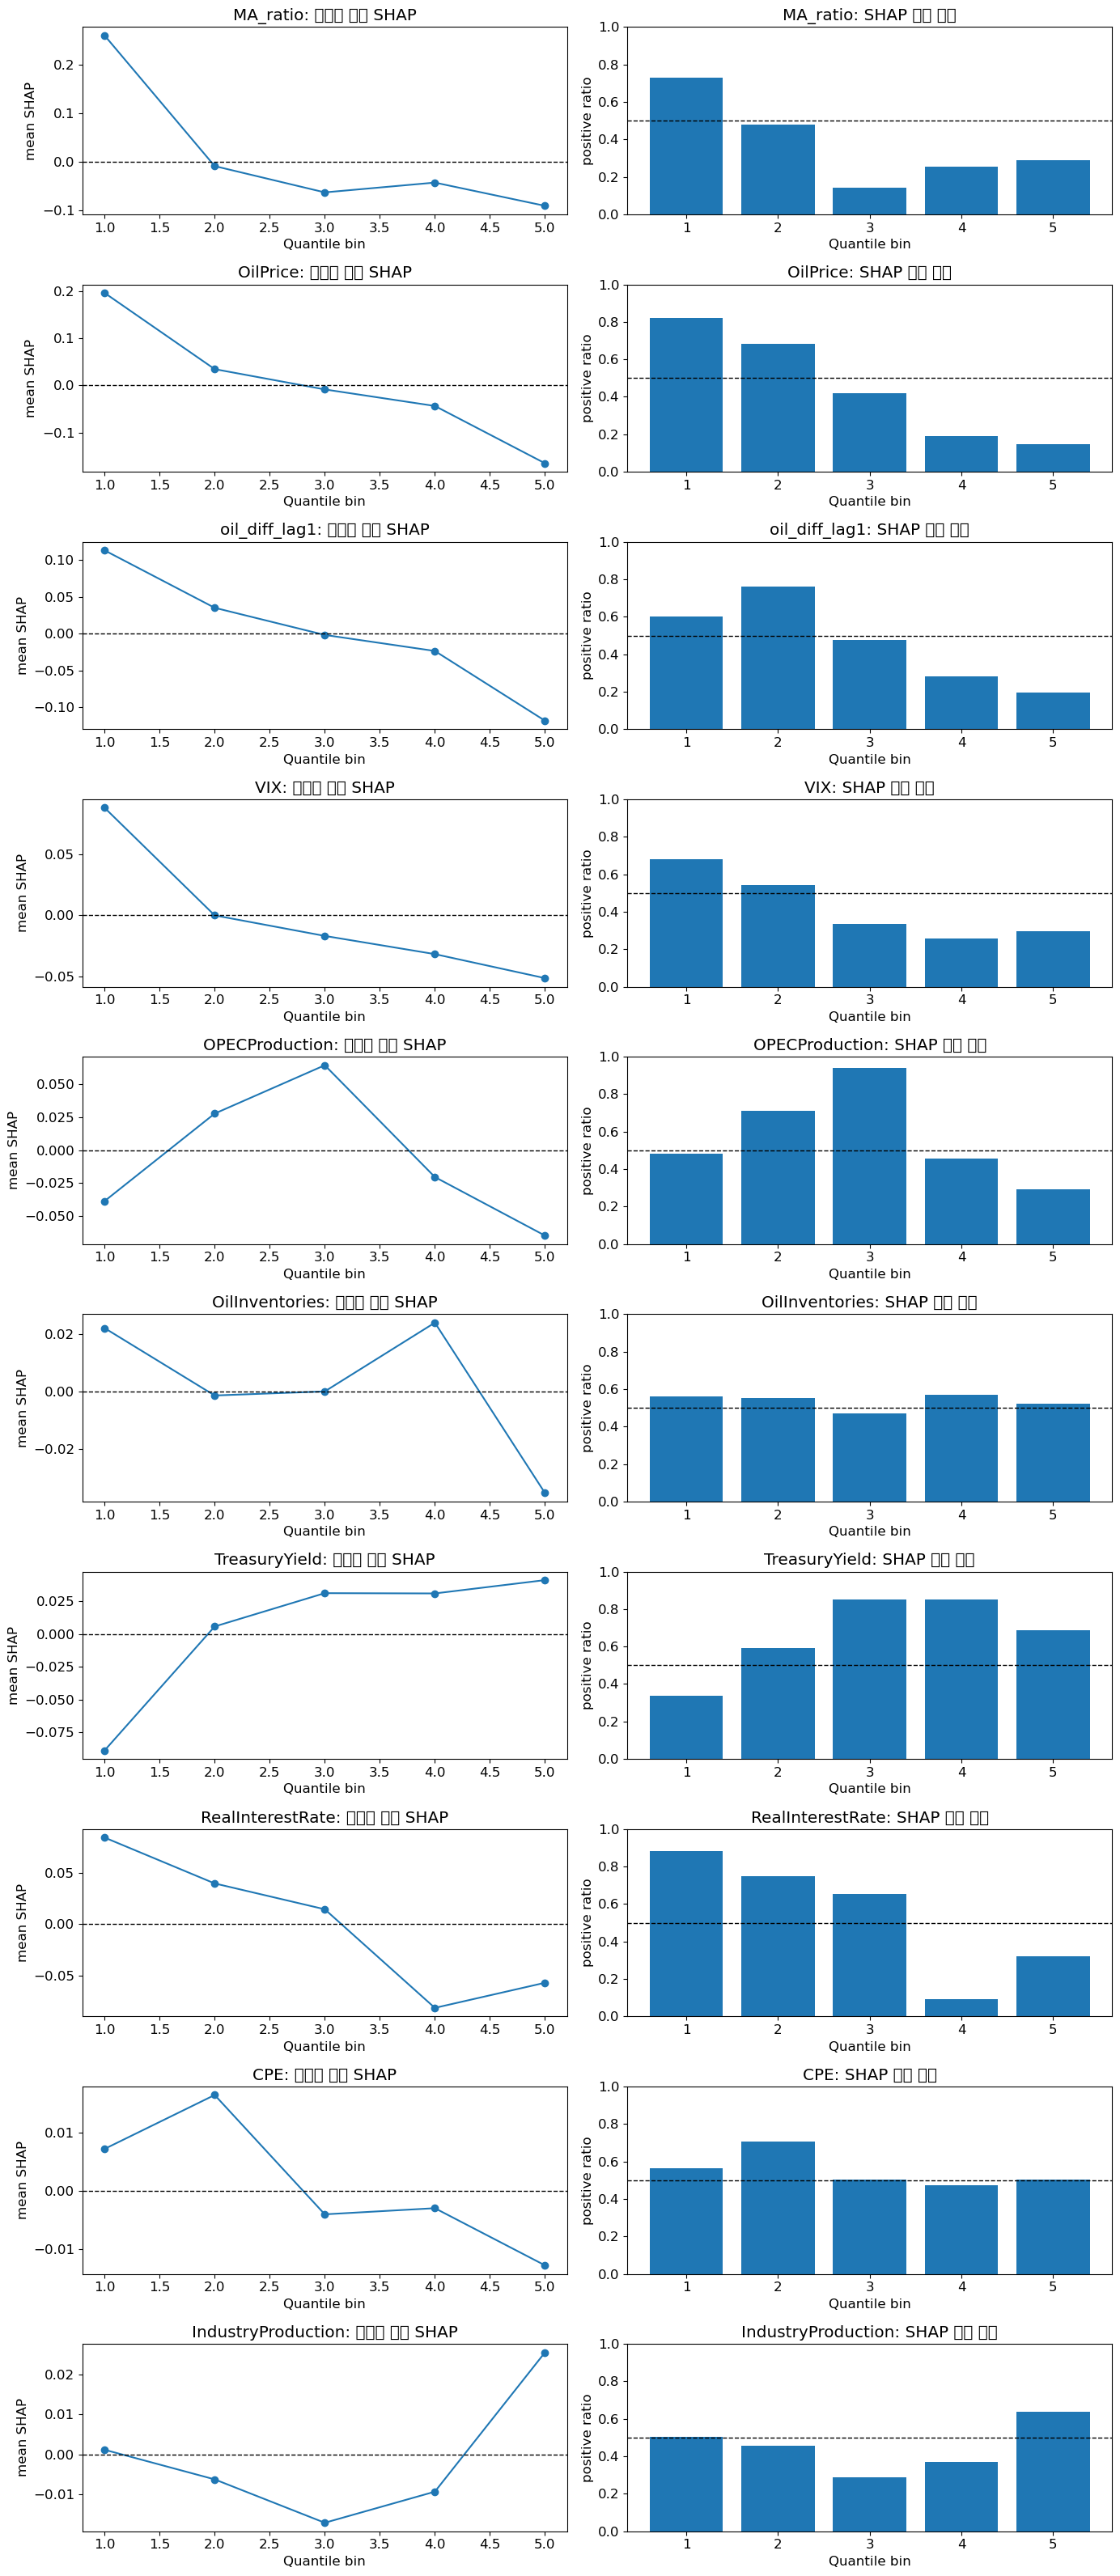

In [14]:
# 변수별로 구간별 평균 SHAP / 양수 비율 시각화
n_vars = len(target_vars)
fig, axes = plt.subplots(n_vars, 2, figsize=(14, 3.2 * n_vars))

if n_vars == 1:
    axes = np.array([axes])

for r, var in enumerate(target_vars):
    sub = shap_bin_summary[shap_bin_summary["variable"] == var].copy()

    axes[r, 0].plot(sub["bin_order"], sub["mean_shap"], marker="o")
    axes[r, 0].axhline(0, color="black", linewidth=1, linestyle="--")
    axes[r, 0].set_title(f"{var}: 구간별 평균 SHAP")
    axes[r, 0].set_xlabel("Quantile bin")
    axes[r, 0].set_ylabel("mean SHAP")

    axes[r, 1].bar(sub["bin_order"], sub["positive_ratio"])
    axes[r, 1].axhline(0.5, color="black", linewidth=1, linestyle="--")
    axes[r, 1].set_ylim(0, 1)
    axes[r, 1].set_title(f"{var}: SHAP 양수 비율")
    axes[r, 1].set_xlabel("Quantile bin")
    axes[r, 1].set_ylabel("positive ratio")

fig.tight_layout()
fig.savefig(BASELINE_DIR / "shap_bin_sign_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

[해석]
- `MA_ratio`, `OilPrice`, `oil_volatility_20`, `oil_diff_lag1`, `OilInventories`, `VIX`는 구간별 SHAP 부호 전환이 뚜렷하여 비선형 효과가 의심된다. 
- `CPE`와 `RealInterestRate`는 부호 변화가 불규칙해 단독 비선형보다는 상호작용 가능성이 크며 dependence plot을 확인할 필요가 있다. 

| 구분 | 변수 | 구간별 SHAP 패턴 | 해석 |
|---|---|---|---|
| 비선형 의심 | `MA_ratio` | 1구간 `+`, 2~5구간 `-` | 낮은 구간에서만 강한 양의 효과가 나타나 평균 부호만으로 해석하기 어려움 |
| 비선형 의심 | `OilPrice` | 낮은 구간 `+`, 높은 구간 `-` | 가격 변화 수준에 따라 예측 기여 방향이 전환됨 |
| 비선형 의심 | `oil_volatility_20` | 중간 구간 `+`, 최고 구간 `-` | 변동성 수준에 따라 효과 방향이 달라지는 threshold형 패턴 |
| 비선형 의심 | `oil_diff_lag1` | 낮은 구간 `+`, 높은 구간 `-` | 전일 변화가 큰 양수일 때 반전 효과 가능 |
| 비선형 의심 | `OilInventories` | 낮은 재고 `+`, 높은 재고 `-` | 재고 수준에 따라 효과 방향이 달라지며, 경제적으로 해석 가능 |
| 비선형 의심 | `VIX` | 낮은 구간 `+`, 중간 이상 `-` | VIX 변화 수준에 따라 효과 방향이 전환됨 |
| 상호작용 의심 | `CPE` | `-`, `+`, `+`, `-`, `+` | 구간별 방향이 불규칙해 단독 비선형보다 다른 변수와의 상호작용 가능성 |
| 상호작용 의심 | `RealInterestRate` | `-`, `+`, `-`, `-`, `+` | 구간별 부호가 안정적이지 않아 상호작용 가능성 |
| 약하거나 애매 | `IndustryProduction` | 부호 혼재, 평균 SHAP 작음 | 구간별 패턴이 뚜렷하지 않고 영향력이 상대적으로 약함 |


In [15]:
# 저장
shap_bin_summary.to_csv(BASELINE_DIR / "shap_bin_sign_distribution.csv", index=False)
print("저장 완료:")
print(" -", BASELINE_DIR / "shap_bin_sign_distribution.csv")
print(" -", BASELINE_DIR / "shap_bin_sign_distribution.png")

저장 완료:
 - ../outputs/baseline/shap_bin_sign_distribution.csv
 - ../outputs/baseline/shap_bin_sign_distribution.png


## 9. 비선형 효과 보강 분석

### 9-1. PDP를 통한 LGBM 비선형 패턴 확인

In [16]:
from sklearn.inspection import PartialDependenceDisplay
import math

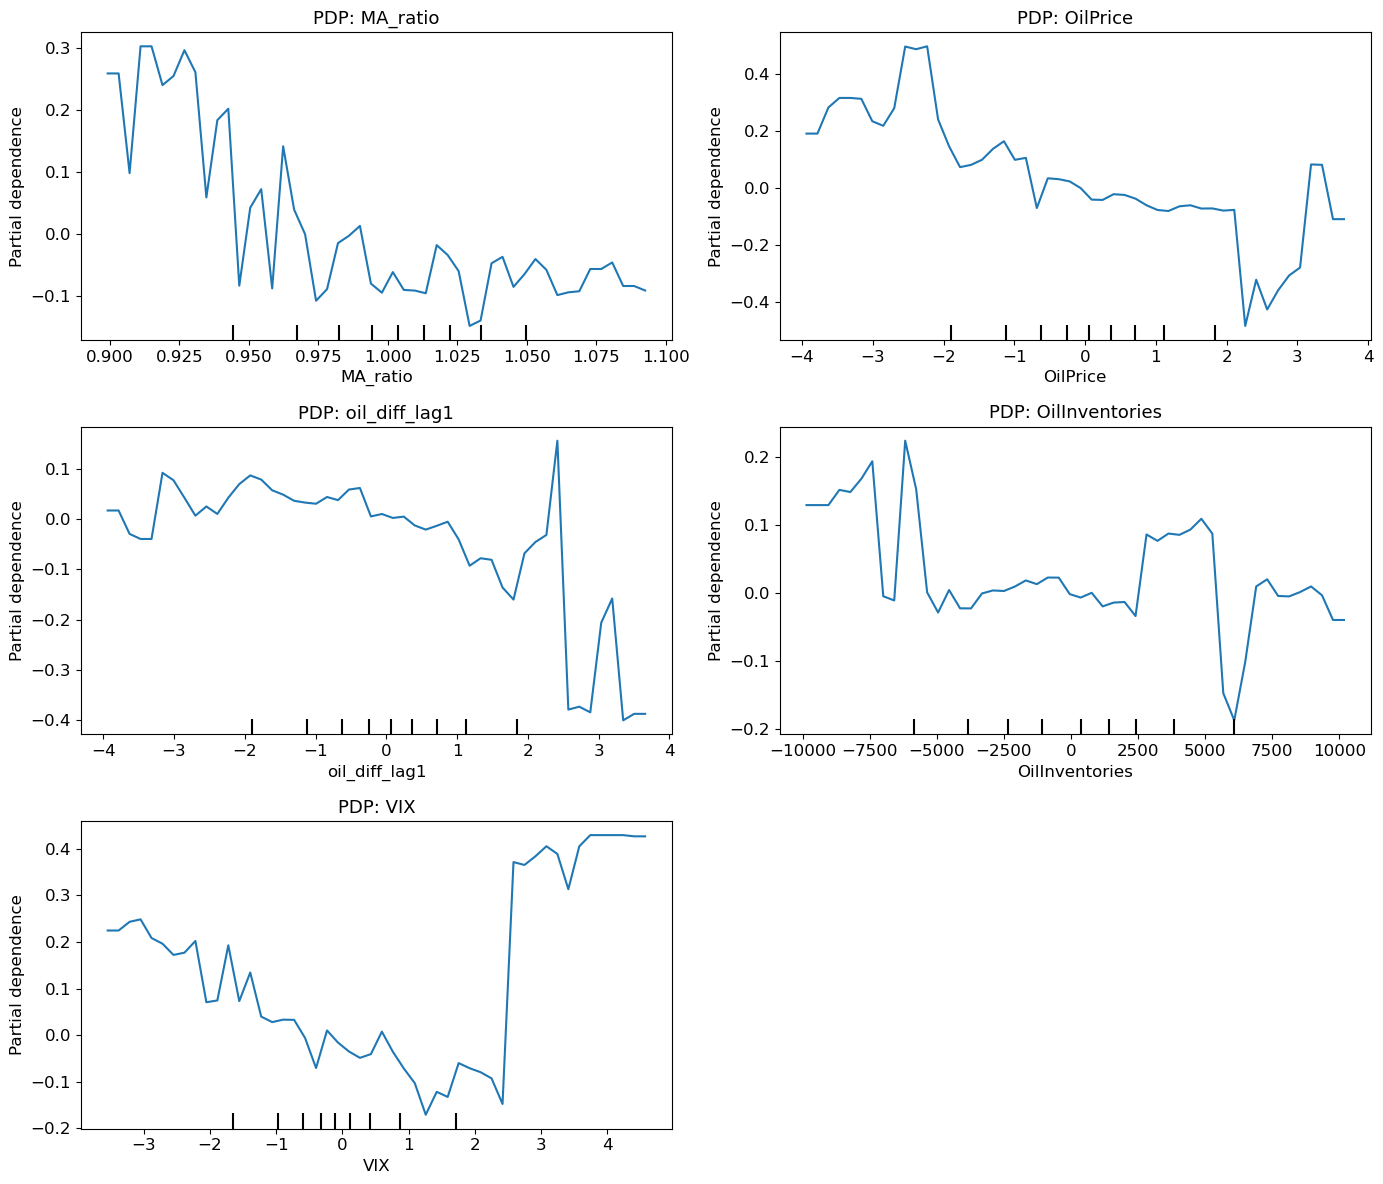

저장 완료:
 - ../outputs/baseline/pdp_nonlinear_suspects.png


In [17]:
# 비선형 효과 의심 변수
pdp_vars = [
    "MA_ratio",
    "OilPrice",
    "oil_volatility_20",
    "oil_diff_lag1",
    "OilInventories",
    "VIX",
]

pdp_vars = [v for v in pdp_vars if v in X.columns]

n_cols = 2
n_rows = math.ceil(len(pdp_vars) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, var in enumerate(pdp_vars):
    PartialDependenceDisplay.from_estimator(
        lgbm,
        X,
        [var],
        kind="average", # 전체 평균 예측 변화
        grid_resolution=50,
        percentiles=(0.02, 0.98), # 극단값 제외
        ax=axes[i],
    )
    axes[i].set_title(f"PDP: {var}", fontsize=13)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Average prediction")

for j in range(len(pdp_vars), len(axes)):
    axes[j].axis("off")

fig.tight_layout()

save_path = BASELINE_DIR / "pdp_nonlinear_suspects.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")

plt.show()

print("저장 완료:")
print(" -", save_path)

[해석]
- PDP가 거의 직선: 선형 효과에 가까움
- 중간에 꺾임: threshold 또는 구간별 효과 가능성 (MA_ratio, oil_volatility_20)
- 상승 후 하락: 역U형 또는 반전 효과 (OilPrice 일부, OilInventories)
- 하락 후 상승: U자형 비선형 효과 (VIX)
- 특정 구간에서만 급변: 해당 구간에서 LGBM이 강하게 반응 (MA_ratio, OilPrice, oil_volatility_20, oil_diff_lag1)

*OilPrice, oil_diff_lag1의 경우에는 극단 구간에서 강한 반응이 관찰됨*

=> SHAP 구간별 부호 분석에서 비선형 의심으로 분류된 변수들은 LGBM의 평균 예측 함수에서도 대체로 구간별 패턴을 보였다. 이는 일부 변수 효과가 평균적인 선형 관계보다 시장 국면에 따라 달라질 수 있음을 시사한다.

### 결론

OLS는 변수의 평균적인 선형 효과를 보여주기 때문에, 변수 값의 구간이나 시장 국면에 따라 효과가 달라지는 경우를 충분히 포착하기 어렵다. 
반면 LGBM-SHAP은 특정 변수의 기여도가 구간별로 달라지거나, 다른 변수와 함께 작용하는 패턴을 보여줄 수 있다.
따라서 비선형 체크는 OLS에서 유의하지 않거나 평균 효과가 약하게 나타난 변수가 LGBM에서는 왜 중요하게 나타났는지 설명하는 역할을 한다. 
뉴스나 이벤트 기반 정보 또한 모든 시점에서 일정하게 작용하기보다, 특정 시장 국면이나 변동성 수준에서 더 강하게 작용할 가능성이 있다. 
이러한 점에서 OLS와 LGBM-SHAP의 비교는 뉴스데이터가 단순 선형 평균 효과로는 포착되지 않는 보완적 정보를 제공할 수 있음을 보여준다.

## 10. 상호작용 의심변수 재확인
→ 구간별 부호가 불규칙했던 CPE, RealInterestRate 집중 확인

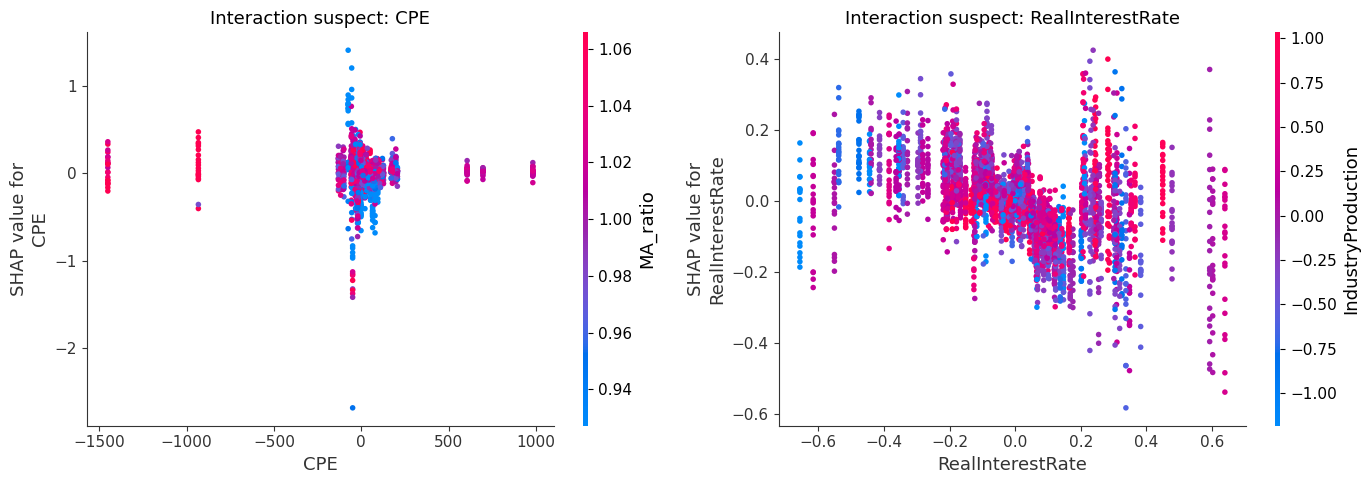

In [18]:
# 상호작용 의심 변수 확인
interaction_suspect_vars = ["CPE", "RealInterestRate"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes = axes.flatten()
for i, var in enumerate(interaction_suspect_vars):
    shap.dependence_plot(var, shap_values, X, ax=axes[i], show=False, interaction_index='auto')
    axes[i].set_title(f'Interaction suspect: {var}', fontsize=13)

fig.tight_layout()
fig.savefig(BASELINE_DIR / 'dependence_interaction_suspects.png', dpi=150, bbox_inches='tight')
plt.show()

[해석]

- `CPE`의 상호작용 후보: `RealInterestRate`
- `RealInterestRate`의 상호작용 후보: `VIX`

구간별 SHAP 부호 분석에서 CPE와 RealInterestRate는 방향이 불규칙하게 나타났고, dependence plot에서도 단순한 비선형 곡선보다는 다른 변수 수준에 따라 효과가 달라지는 패턴을 보이고 있다. 그러므로 두 변수는 단독 효과보다는 상호작용 관점에서 해석하는 것이 더 적절하다.

## 11. 양면 bar chart (paired importance)

/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_45185/937111570.py:21: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_45185/937111570.py:21: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_45185/937111570.py:21: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_45185/937111570.py:21: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_45185/937111570.py:21: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_45

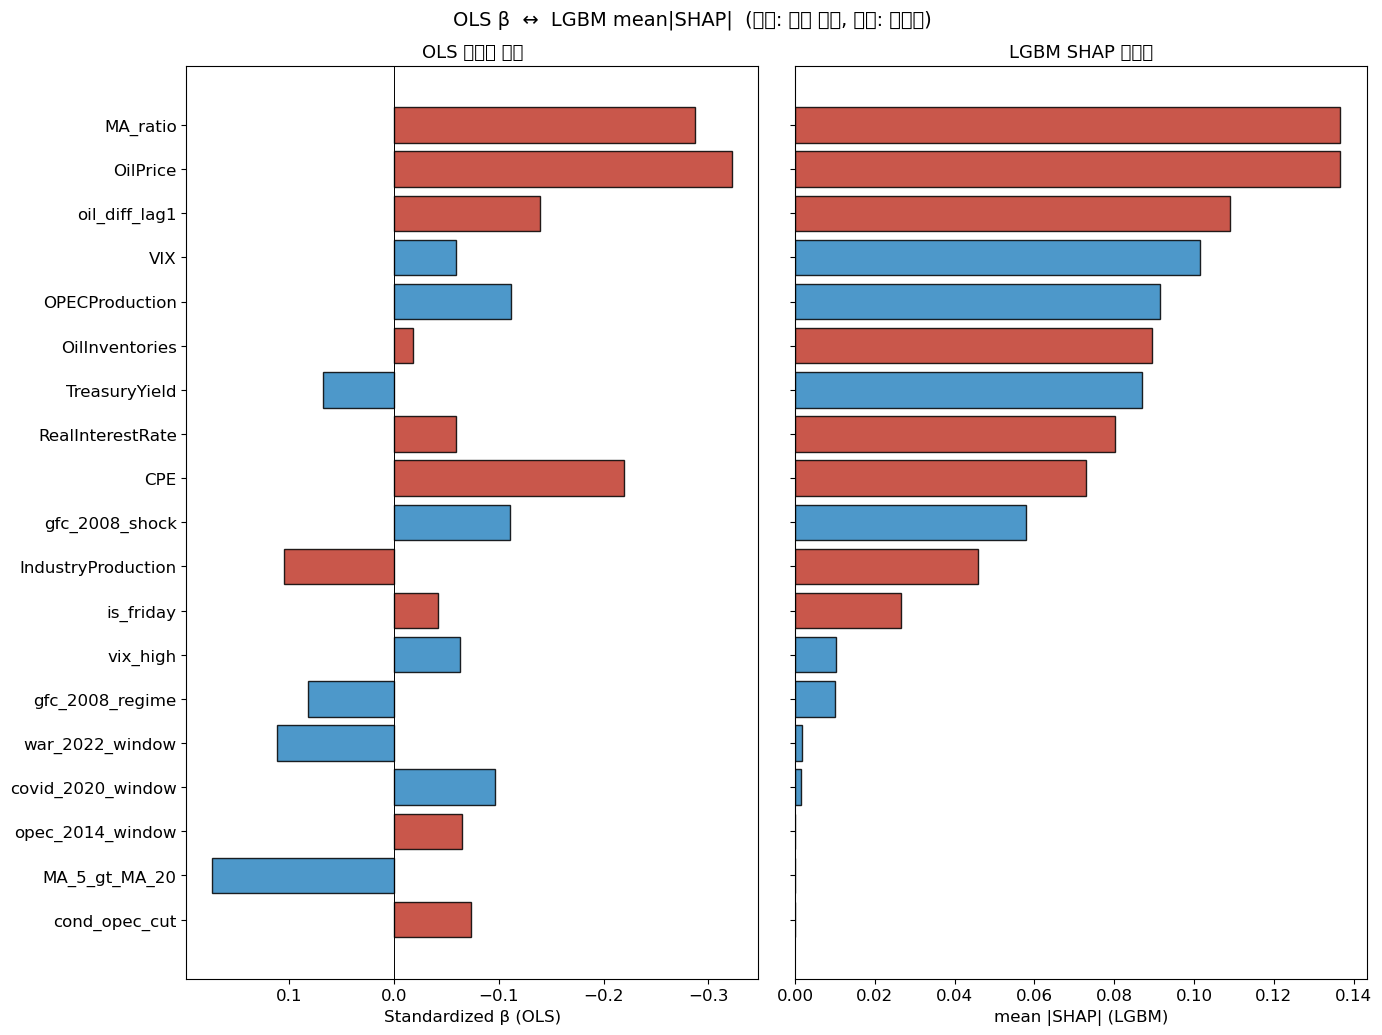

In [19]:
order = cmp.sort_values('mean_abs_shap', ascending=True).reset_index(drop=True)
yloc = np.arange(len(order))

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 0.45 * len(order) + 2), sharey=True)

colors = ['#2E86C1' if m else '#C0392B' for m in order['sign_match']]

ax_l.barh(yloc, order['std_beta_OLS'], color=colors, edgecolor='black', alpha=0.85)
ax_l.axvline(0, color='black', lw=0.7)
ax_l.invert_xaxis()
ax_l.set_yticks(yloc)
ax_l.set_yticklabels(order['variable'])
ax_l.set_xlabel('Standardized β (OLS)', fontsize=12)
ax_l.set_title('OLS 표준화 계수', fontsize=13)

ax_r.barh(yloc, order['mean_abs_shap'], color=colors, edgecolor='black', alpha=0.85)
ax_r.set_xlabel('mean |SHAP| (LGBM)', fontsize=12)
ax_r.set_title('LGBM SHAP 중요도', fontsize=13)

fig.suptitle('OLS β  ↔  LGBM mean|SHAP|  (파랑: 부호 일치, 빨강: 불일치)', fontsize=14)
fig.tight_layout()
fig.savefig(BASELINE_DIR / 'paired_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. 케이스별 해석 문장 자동 생성

In [20]:
for _, row in cmp.iterrows():
    beta = row['std_beta_OLS']
    p = row['p_HC3']
    mshap = row['mean_abs_shap']
    p_txt = f'p<0.01' if p < 0.01 else (f'p<0.05' if p < 0.05 else f'p={p:.3f}')
    sign_txt = '부호 일치' if row['sign_match'] else '부호 불일치'
    print(f"{row['variable']:25s} | OLS β = {beta:+.4f} ({p_txt}), mean|SHAP| = {mshap:.4f} | {sign_txt} → {row['case']}")

MA_ratio                  | OLS β = -0.2869 (p=0.145), mean|SHAP| = 0.1365 | 부호 불일치 → 순수 비선형 효과
OilPrice                  | OLS β = -0.3229 (p=0.263), mean|SHAP| = 0.1365 | 부호 불일치 → 순수 비선형 효과
oil_diff_lag1             | OLS β = -0.1394 (p<0.05), mean|SHAP| = 0.1090 | 부호 불일치 → 상호작용 의심
VIX                       | OLS β = -0.0591 (p=0.177), mean|SHAP| = 0.1016 | 부호 일치 → 순수 비선형 효과
OPECProduction            | OLS β = -0.1113 (p=0.077), mean|SHAP| = 0.0914 | 부호 일치 → 순수 비선형 효과
OilInventories            | OLS β = -0.0188 (p=0.747), mean|SHAP| = 0.0894 | 부호 불일치 → 순수 비선형 효과
TreasuryYield             | OLS β = +0.0671 (p=0.259), mean|SHAP| = 0.0869 | 부호 일치 → 약한 효과
RealInterestRate          | OLS β = -0.0596 (p=0.090), mean|SHAP| = 0.0801 | 부호 불일치 → 상호작용 의심
CPE                       | OLS β = -0.2194 (p=0.066), mean|SHAP| = 0.0729 | 부호 불일치 → 상호작용 의심
gfc_2008_shock            | OLS β = -0.1109 (p=0.218), mean|SHAP| = 0.0578 | 부호 일치 → 약한 효과
IndustryProduction        | OLS β = +0.1045 (p=0.167), mean

## 13. 저장

In [21]:
shap_summary.to_csv(BASELINE_DIR / 'lgbm_shap_summary.csv', index=False)
cmp.to_csv(BASELINE_DIR / 'interpretation_compare.csv', index=False)
np.save(BASELINE_DIR / 'shap_values.npy', shap_arr)

print('저장 완료:')
for f in ['lgbm_shap_summary.csv', 'interpretation_compare.csv', 'shap_values.npy',
          'shap_summary.png', 'shap_summary_bar.png', 'dependence_top5.png', 'paired_importance.png']:
    print(' -', BASELINE_DIR / f)

저장 완료:
 - ../outputs/baseline/lgbm_shap_summary.csv
 - ../outputs/baseline/interpretation_compare.csv
 - ../outputs/baseline/shap_values.npy
 - ../outputs/baseline/shap_summary.png
 - ../outputs/baseline/shap_summary_bar.png
 - ../outputs/baseline/dependence_top5.png
 - ../outputs/baseline/paired_importance.png


## 최종결론

[흐름]

